<a href="https://colab.research.google.com/gist/SoKawai1/9605446540b9da2f05235b5b0c4e1c1d/anime_faces_classification_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект **"Anime expressions classification"**

Материалы:
*   [Nagadomis LBP cascade](https://github.com/nagadomi/lbpcascade_animeface)
*   [Danbooru (Датасет)](https://danbooru.donmai.us/)
---
Дата: 21.01.2025

Импортирование библиотек

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import files, drive
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns
import sys
import zipfile
from PIL import Image
import albumentations as A
from tqdm import tqdm

Подключение к google drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


Загрузка дата сета

In [6]:
zip_path = ["/content/drive/MyDrive/smiling_expressions_df_beta.zip", "/content/drive/MyDrive/crying_expressions_df.zip"]  #Путь к дата сету в google drive
extract_path = "/content/"

for i in range(len(zip_path)):
    with zipfile.ZipFile(zip_path[i], 'r') as zip_ref:
      zip_ref.extractall(extract_path)

Присвоение классов к каждой картинке

In [7]:
def create_labeled_dataset(folder_paths, labels, target_size=(128, 128)):
    images = []
    targets = []

    for folder, label in zip(folder_paths, labels):
        for filename in os.listdir(folder):
            file_path = os.path.join(folder, filename)
            if os.path.isfile(file_path):
                try:
                    img = Image.open(file_path).convert("L") #Преобразуем все изображения в Ч/Б формат
                    img = img.resize(target_size) #Переформатируем размер изображений
                    images.append(np.array(img)) #Добавляем изображения в список в виде np.array
                    targets.append(label) #Добавляем lable к каждому изображению (0 = happy, 1 = sad)
                except Exception as e:
                    print(f"Ошибка при обработке файла {file_path}: {e}")

    #Преобразуем списки в numpy массивы
    X = np.array(images)
    y = np.array(targets)
    return X, y

In [8]:
folders = ["smiling_expressions_df_beta", "crying_expressions_df"] #Названия папок с изображениями
labels = [0,1] #0 = happy, 1 = sad

X, y = create_labeled_dataset(folders, labels, target_size=(128, 128)) #Используем функцию на наших изображениях
X = X / 255.0 #Нормализация

Функция для показа изображений

In [11]:
classes = ['happy', 'sad']

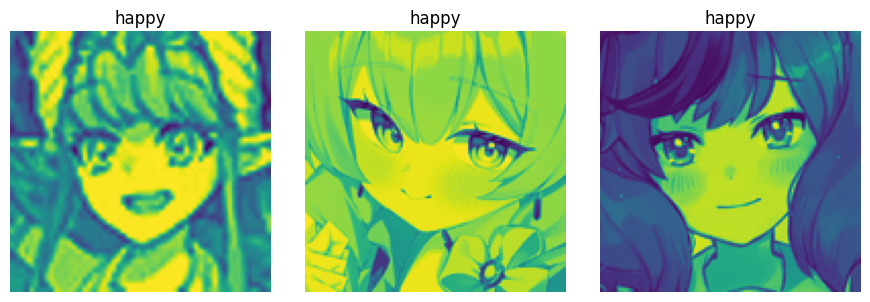

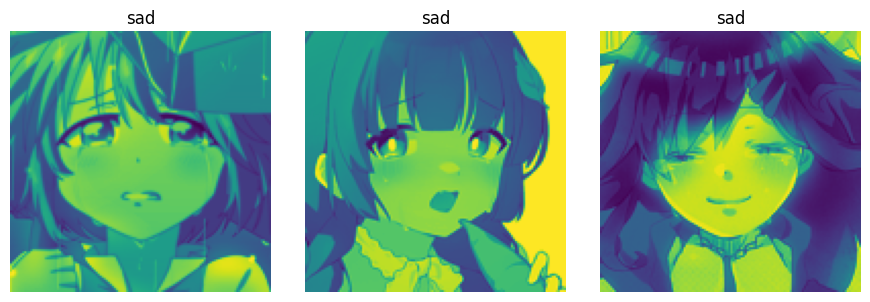

In [12]:
def plot_samples(X, y, indices, classes):
    num_samples = len(indices)
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 3, 3))

    for i, ax in enumerate(axes):
        ax.imshow(X[indices[i]])
        ax.set_title(classes[y[indices[i]]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()
plot_samples( X, y, list(range(100,103)), classes)
plot_samples( X, y, list(range(1205,1208)), classes)

# Аугментация данных

In [15]:
pillow_image = Image.open("Chi.jpg")
image = np.array(pillow_image)

Масштабирование

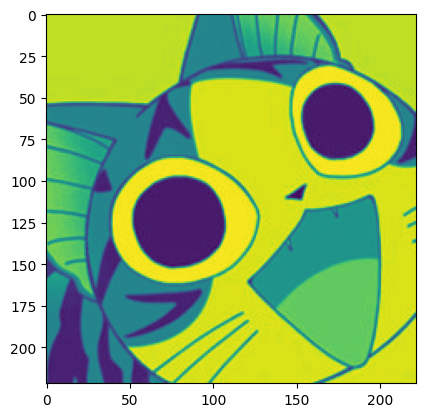

In [16]:
random_crop = A.Compose([
    A.RandomCrop(width=222, height=222),
    #A.RandomBrightnessContrast(p=0.2),
])
transformed = random_crop(image=image)
transformed = np.array(transformed['image'])
plt.imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2GRAY))
plt.show()

Отзеркаливание

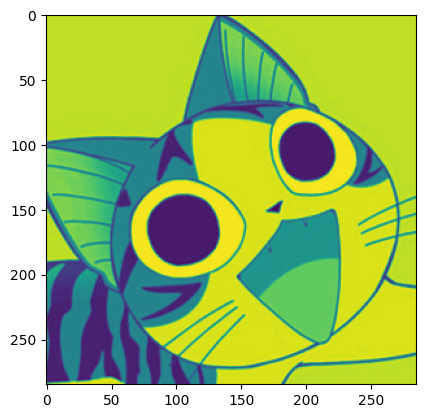

In [ ]:
flip = A.Compose([
    A.HorizontalFlip(p=0.5),
])
transformed = flip(image=image)
transformed = np.array(transformed['image'])
plt.imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2GRAY))
plt.show()

Изменение контраста

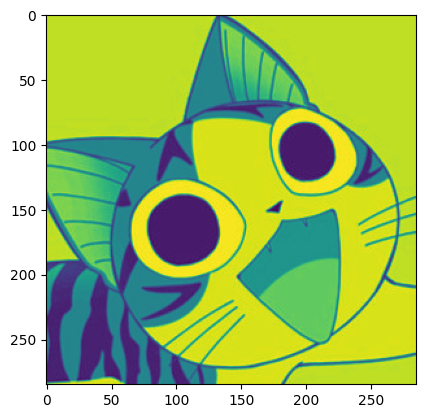

In [ ]:
pillow_image = Image.open("Chi.jpg")
image = np.array(pillow_image)
random_contrast = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
])
transformed = random_contrast(image=image)
transformed = np.array(transformed['image'])
plt.imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2GRAY))
plt.show()

Характеристики для аугментации

In [ ]:
augmentation = A.Compose([
    A.RandomCrop(width=100, height=100),  # Случайное кадрирование
    A.HorizontalFlip(p=0.5),  # Отражение
    #A.RandomBrightnessContrast(p=0.2),  # Яркость и контраст
    #A.GaussNoise(p=0.2)  # Шум
])

In [ ]:
def augment_data(X, y, augment_factor=2):
    X_aug, y_aug = [], []
    for i in tqdm(range(len(X)), desc="Аугментация изображений"):
        for _ in range(augment_factor):
            # Применяем аугментацию
            transformed = augmentation(image=X[i])["image"]
            transformed = cv2.resize(transformed, (128, 128))
            X_aug.append(transformed)
            y_aug.append(y[i])  # Метка остаётся той же

    return np.array(X_aug), np.array(y_aug)


X_augmented, y_augmented = augment_data(X, y, augment_factor=2)

X_final = np.concatenate((X, X_augmented), axis=0)
y_final = np.concatenate((y, y_augmented), axis=0)


Аугментация изображений: 100%|██████████| 2303/2303 [00:01<00:00, 1959.46it/s]


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33) #Разделение данных на тренировочные 80% и тестовые 20%

Обзор датасета после аугментации

In [ ]:
X.shape, X_final.shape

((2303, 128, 128), (6909, 128, 128))

In [ ]:
X_augmented.shape

(4606, 128, 128)

Результат после аугментации:

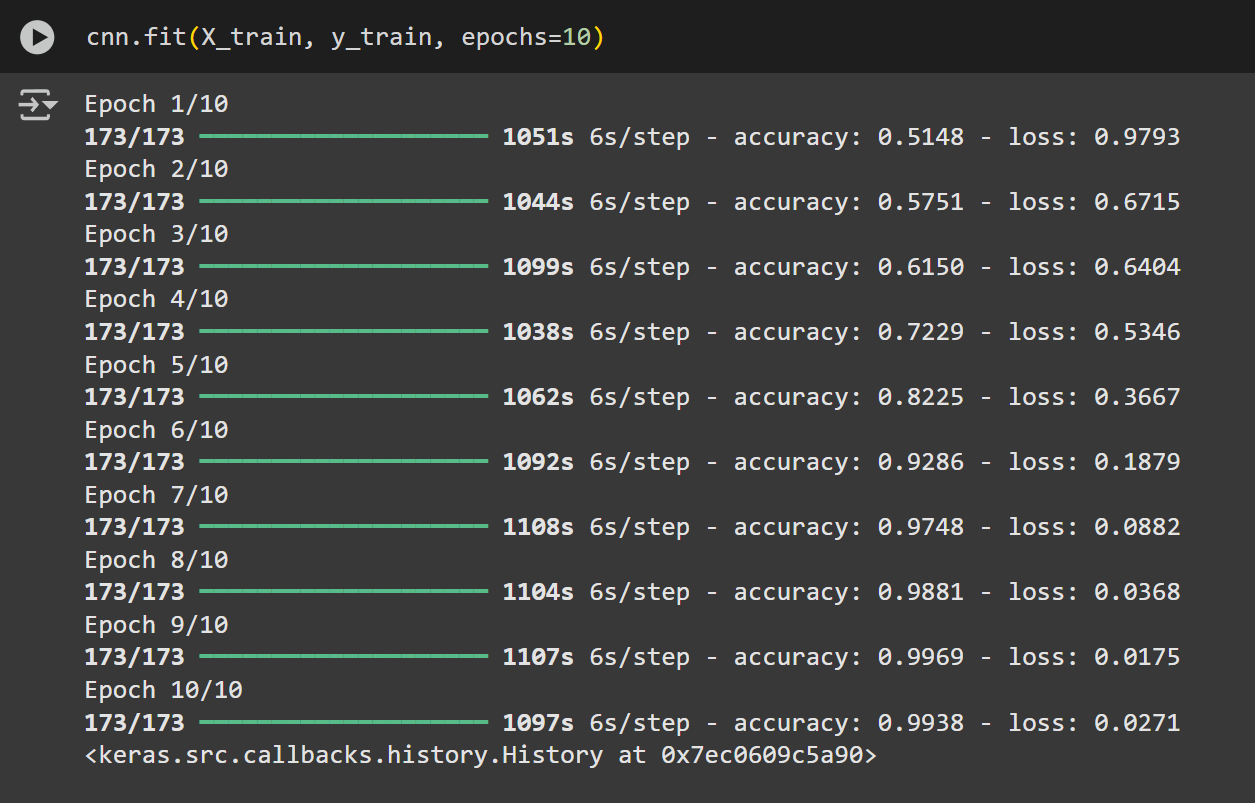

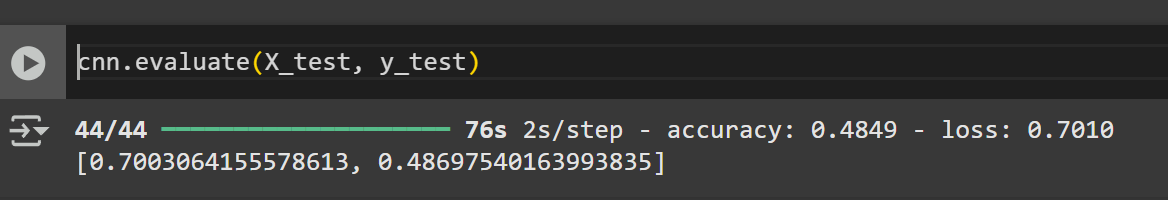

Переобучение. Модель фактически делает прогнозы в слепую. 💩

# Построение модели на CNN tensorflow

In [32]:
cnn = models.Sequential([
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', input_shape=(128,128, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Настройка функции потерь, оптимизатора и метрики

In [33]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Обучение модели

In [34]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 350s 6s/step - accuracy: 0.4982 - loss: 1.7197
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 369s 6s/step - accuracy: 0.5382 - loss: 0.6878
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.5780 - loss: 0.6658
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.6635 - loss: 0.6030
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 379s 6s/step - accuracy: 0.7143 - loss: 0.5407
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 334s 6s/step - accuracy: 0.8245 - loss: 0.3867
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.8898 - loss: 0.2773
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 333s 6s/step - accuracy: 0.9346 - loss: 0.1613
Epoch 9/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.9723 - loss: 0.0977
Epoch 10/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 385s 6s/step - accuracy: 0.9922 - loss: 0.0461


Испытание на тестовом датасете

In [35]:
cnn.evaluate(X_test, y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6999 - loss: 1.4271


[1.334311604499817, 0.7201735377311707]

In [37]:
y_pred = cnn.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.71      0.76      0.73       233
           1       0.73      0.68      0.71       228

    accuracy                           0.72       461
   macro avg       0.72      0.72      0.72       461
weighted avg       0.72      0.72      0.72       461



In [27]:
def correct_incorrect_img(X, y_true, y_pred, indices, classes): #Функция для создания рамки вокруг картинок и установления цвета, в зависимости от правильности
    num_samples = len(indices)
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 3, 3))
    for i, ax in enumerate(axes):
        idx = indices[i]
        ax.imshow(X[idx])
        ax.set_title(classes[y_pred[idx]])
        ax.axis('on')

        color = 'red' if y_true[idx] != y_pred[idx] else 'green'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(6)

    plt.tight_layout()
    plt.show()


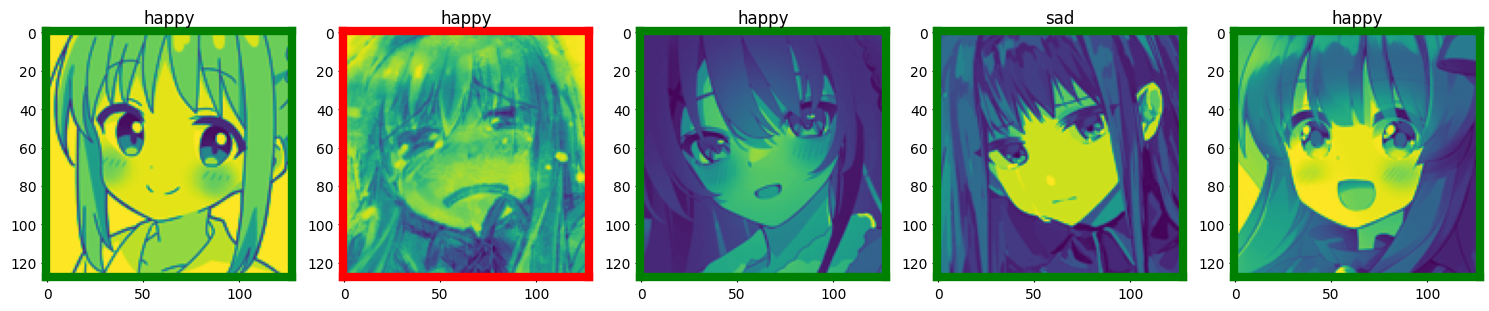

In [39]:
y_classes = [np.argmax(element) for element in y_pred]
correct_incorrect_img(X_test, y_test, y_classes, list(range(20,25)), classes)